In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_curve,roc_auc_score
from sklearn.metrics import precision_score,recall_score,f1_score
df=pd.read_csv('train_u6lujuX_CVtuZ9i (1).csv')
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [2]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [4]:
df.shape

(614, 13)

In [5]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [6]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [7]:
df=df.dropna()

In [8]:
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [9]:
df.shape

(480, 13)

In [10]:
# Label Encoding

df.replace({"Loan_Status":{'N':0,'Y':1}},inplace=True)

C:\Users\mruna\AppData\Local\Temp\ipykernel_13128\1518758488.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({"Loan_Status":{'N':0,'Y':1}},inplace=True)
C:\Users\mruna\AppData\Local\Temp\ipykernel_13128\1518758488.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.replace({"Loan_Status":{'N':0,'Y':1}},inplace=True)


In [11]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,0
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,1
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,1
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,1
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,1


In [12]:
df['Dependents'].value_counts()

Dependents
0     274
2      85
1      80
3+     41
Name: count, dtype: int64

In [13]:
df=df.replace(to_replace='3+',value=4)

In [14]:
df['Dependents'].value_counts()

Dependents
0    274
2     85
1     80
4     41
Name: count, dtype: int64

**Data Visualization**

<Axes: xlabel='Education', ylabel='count'>

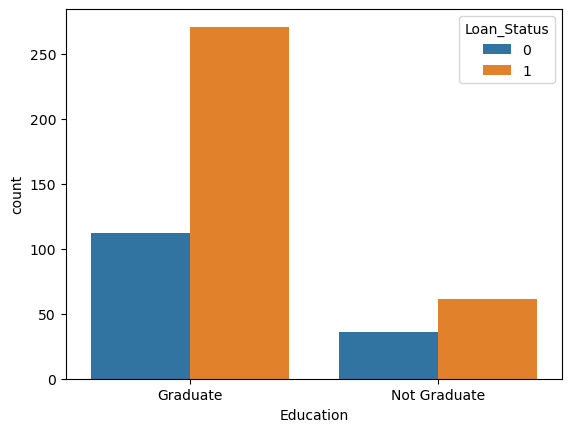

In [15]:
sns.countplot(x="Education",hue="Loan_Status",data=df)

<Axes: xlabel='Married', ylabel='count'>

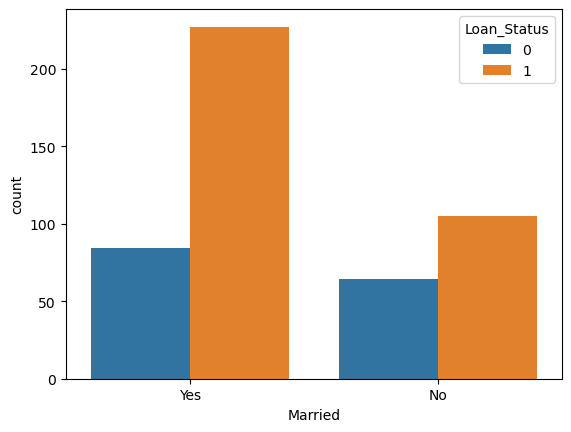

In [16]:
sns.countplot(x="Married",hue="Loan_Status",data=df)

In [17]:
df.replace({"Gender":{'Male':1,'Female':0},"Married":{'Yes':1,'No':0},"Self_Employed":{'Yes':1,'No':0},"Property_Area":{'Rural':0,'Semiurban':1,'Urban':2},"Education":{'Graduate':1,'Not Graduate':0}},inplace=True)

C:\Users\mruna\AppData\Local\Temp\ipykernel_13128\17176928.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({"Gender":{'Male':1,'Female':0},"Married":{'Yes':1,'No':0},"Self_Employed":{'Yes':1,'No':0},"Property_Area":{'Rural':0,'Semiurban':1,'Urban':2},"Education":{'Graduate':1,'Not Graduate':0}},inplace=True)


In [18]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
1,LP001003,1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,0,0
2,LP001005,1,1,0,1,1,3000,0.0,66.0,360.0,1.0,2,1
3,LP001006,1,1,0,0,0,2583,2358.0,120.0,360.0,1.0,2,1
4,LP001008,1,0,0,1,0,6000,0.0,141.0,360.0,1.0,2,1
5,LP001011,1,1,2,1,1,5417,4196.0,267.0,360.0,1.0,2,1


In [19]:
df.drop(columns='Loan_ID',axis=1,inplace=True)

In [20]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
1,1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,0,0
2,1,1,0,1,1,3000,0.0,66.0,360.0,1.0,2,1
3,1,1,0,0,0,2583,2358.0,120.0,360.0,1.0,2,1
4,1,0,0,1,0,6000,0.0,141.0,360.0,1.0,2,1
5,1,1,2,1,1,5417,4196.0,267.0,360.0,1.0,2,1


In [21]:
x=df.drop('Loan_Status',axis=1)
y=df['Loan_Status']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.1,stratify=y,random_state=42)

In [22]:
pipeline=Pipeline([('scaler',StandardScaler()),
                   ('log_reg',LogisticRegression(max_iter=614,random_state=42))
                  ])
pipeline.fit(x_train,y_train)
y_pred_test=pipeline.predict(x_test)
y_pred_train=pipeline.predict(x_train)

print("Accuracy : ",accuracy_score(y_test,y_pred_test))
print("Accuracy : ",accuracy_score(y_train,y_pred_train))


Accuracy :  0.7916666666666666
Accuracy :  0.8101851851851852


<Axes: >

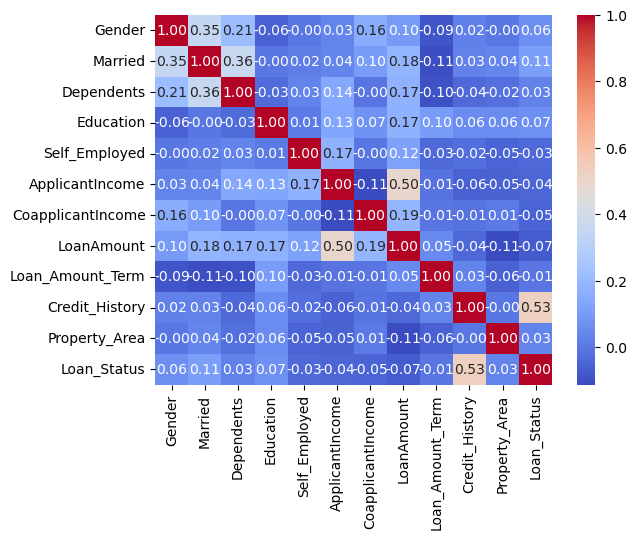

In [23]:
#Feature Extraction
sns.heatmap(df.corr(),annot=True,cmap='coolwarm',fmt='.2f')


In [24]:
#Confusion Matrix

cm=confusion_matrix(y_test,y_pred_test)
print("Confusion Matrix : \n",cm)
print("Accuracy : ",accuracy_score(y_test,y_pred_test))
print("Precision : ",precision_score(y_test,y_pred_test))
print("Recall : ",recall_score(y_test,y_pred_test))
print("F1 Score : ",f1_score(y_test,y_pred_test))

Confusion Matrix : 
 [[ 6  9]
 [ 1 32]]
Accuracy :  0.7916666666666666
Precision :  0.7804878048780488
Recall :  0.9696969696969697
F1 Score :  0.8648648648648649


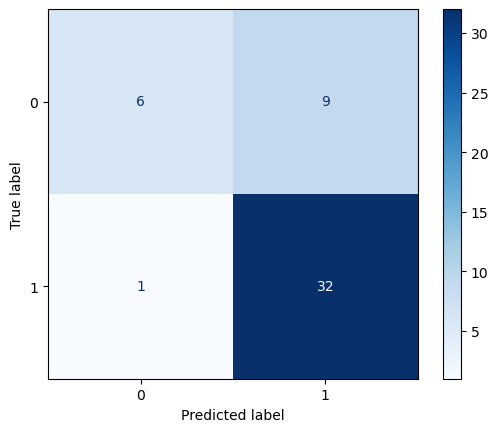

In [25]:
ConfusionMatrixDisplay.from_predictions(y_test,y_pred_test,cmap='Blues')
plt.show()

AUC score :  0.7171717171717172


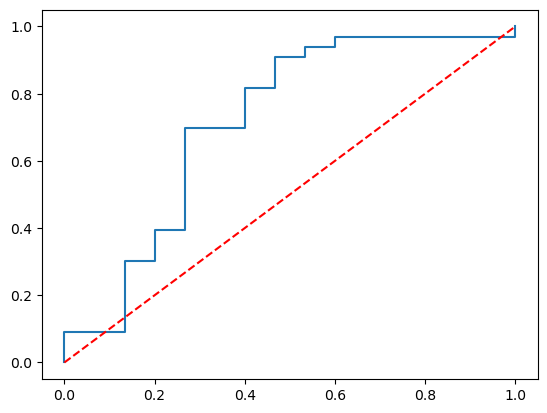

In [26]:
y_prob=pipeline.predict_proba(x_test)[:,1]
fpr,tpr,thresholds = roc_curve(y_test,y_prob)
auc = roc_auc_score(y_test,y_prob)
print("AUC score : ",auc)
plt.plot(fpr,tpr,label=f"AUC={auc:.3f}")
plt.plot([0,1], [0,1], 'r--')
plt.show()

In [27]:
from sklearn.naive_bayes import GaussianNB
from sklearn import svm

model=GaussianNB()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
print("Accuracy by Naive Bayes : ",accuracy_score(y_test,y_pred))

Accuracy by Naive Bayes :  0.7708333333333334


In [ ]:
from sklearn.svm import SVC
classifier = SVC(kernel='linear')

classifier.fit(x_train,y_train)
x_train_prediction = classifier.predict(x_train)
data_accuracy=accuracy_score(x_train_prediction,y_train)
print("Accuracy on training data : ",data_accuracy)

In [ ]:
# KNN
from sklearn.neighbors import KNeighborsClassifier

knn_pipeline = Pipeline([ ('scaler',standardscaler()),
                          ('knn',KNeighborsClassifier(n_neighbors=3))
                        ])
y_pred_train_knn = pipeline_knn.predict(x_train)
y_pred_test_knn = pipeline_knn.predict(x_test)

print("Accuracy in training  : ",accuracy_score(y_train,y_pred_train_knn))
print("Accuracy in testing  : ",accuracy_score(y_test,y_pred_test_knn))